In [122]:
pip install torch torchvision torchaudio 

Note: you may need to restart the kernel to use updated packages.


<h1> Setting Up Dataset and Weights Paths </h1>

In [107]:
import os

# Set up the base directory for dataset and weights
HOME = os.getcwd()
print("HOME:", HOME)

# Define dataset and weights directory
DATASET_PATH = os.path.join(HOME, "dataset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
WEIGHTS_PATH = os.path.join(HOME, "weights")

# Create necessary directories if they don't exist
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(IMAGES_PATH, exist_ok=True)

print(f"✅ Dataset Path: {DATASET_PATH}")
print(f"✅ Images Path: {IMAGES_PATH}")
print(f"✅ Weights Path: {WEIGHTS_PATH}")

HOME: /Users/ma/Documents/samThesis/segment-anything/notebooks
✅ Dataset Path: /Users/ma/Documents/samThesis/segment-anything/notebooks/dataset
✅ Images Path: /Users/ma/Documents/samThesis/segment-anything/notebooks/dataset/images
✅ Weights Path: /Users/ma/Documents/samThesis/segment-anything/notebooks/weights


# Checking PyTorch and MPS Availability

In [111]:
import torch

print("PyTorch Version:", torch.__version__)
print("MPS Available:", torch.backends.mps.is_available())
print("MPS Device:", torch.device("mps") if torch.backends.mps.is_available() else "CPU Only")

PyTorch Version: 2.6.0
MPS Available: True
MPS Device: mps


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

# Define IoU & Dice Score Computations

In [203]:
import torch
import numpy as np

def compute_iou(pred_mask, gt_mask):
    """
    Computes Intersection over Union (IoU)
    Args:
        pred_mask (torch.Tensor): Predicted mask (binary)
        gt_mask (torch.Tensor): Ground truth mask (binary)
    Returns:
        float: IoU score
    """
    # Ensure masks are boolean tensors
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    # Debugging: Print shapes
    print(f"🔍 IoU Calculation - Pred Mask Shape: {pred_mask.shape}, GT Mask Shape: {gt_mask.shape}")

    # Check if both masks are empty (no objects)
    if pred_mask.sum().item() == 0 and gt_mask.sum().item() == 0:
        print("✅ Both masks are empty. Returning IoU = 1.0")
        return 1.0  # Perfect match for empty masks

    # Compute intersection and union
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    union = torch.logical_or(pred_mask, gt_mask).sum().item()

    # Debugging: Print pixel statistics
    print(f"🔍 Overlapping Pixels: {intersection}, Union Pixels: {union}")

    return intersection / union if union > 0 else 0.0


def compute_dice(pred_mask, gt_mask):
    """
    Computes Dice Score (F1-Score for segmentation)
    Args:
        pred_mask (torch.Tensor): Predicted mask (binary)
        gt_mask (torch.Tensor): Ground truth mask (binary)
    Returns:
        float: Dice score
    """
    # Ensure masks are boolean tensors
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    # Compute intersection
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    total = pred_mask.sum().item() + gt_mask.sum().item()

    # Debugging: Print pixel statistics
    print(f"🔍 Dice Calculation - Intersection: {intersection}, Total Pixels in Both Masks: {total}")

    if total == 0:
        print("✅ Both masks are empty. Returning Dice = 1.0")
        return 1.0  # Perfect match for empty masks

    return (2 * intersection) / total

print("✅ IoU & Dice functions are defined!")

✅ IoU & Dice functions are defined!


## Install Segment Anything Model (SAM) and other dependencies

### Download SAM weights

In [119]:
#Installing Dependencies

In [121]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

In [122]:
#Add SAM to Python Path

In [125]:
import sys
import os

# Define your SAM root directory
SAM_ROOT = os.path.join(HOME, "segment-anything")

# Add SAM to the Python path
sys.path.append(SAM_ROOT)

# Print to confirm
print("✅ SAM Local Path Added:", SAM_ROOT)

✅ SAM Local Path Added: /Users/ma/Documents/samThesis/segment-anything/notebooks/segment-anything


In [127]:
#Verify & Set Up the Model Weights

In [129]:
import os

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create the weights directory if it doesn't exist
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Use curl instead of wget
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Successfully downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth


In [131]:
#Download SAM Model Weights (if not available)

In [133]:
if os.path.exists(CHECKPOINT_PATH):
    print("✅ SAM checkpoint successfully downloaded!")
else:
    print("❌ ERROR: Checkpoint download failed.")

✅ SAM checkpoint successfully downloaded!


In [135]:
##Install PennyLane for Quantum Computing
#!pip install pennylane

## Load Segment Anything Model (SAM)

In [138]:
#!pip install segment-anything

In [140]:
from segment_anything import sam_model_registry, SamPredictor
import torch

# Use MPS for Mac M1/M2
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Define the model type and local checkpoint path
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = "/Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth"

# Load the model from the local checkpoint
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

print(f"✅ Successfully loaded SAM model from {CHECKPOINT_PATH} on {DEVICE}")

✅ Successfully loaded SAM model from /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth on mps


## Download Example Data

**NONE:** Let's download few example images.

# Generate 16x16 Shape Dataset

In [144]:
import os

# Define the resolution (only 16x16 for now)
image_size = 16

# Run the command for 16x16 resolution
command = f"cd shapes && python run.py --save_dir ../shapes_dataset_{image_size}x{image_size} --image_size {image_size} {image_size} --num_images 100 --shapes circle rect --task_type segmentation"

print(f"Running: {command}")  # Print to track progress
os.system(command)  # Execute the command

print("✅ Dataset generation complete for 16x16 resolution.")

Running: cd shapes && python run.py --save_dir ../shapes_dataset_16x16 --image_size 16 16 --num_images 100 --shapes circle rect --task_type segmentation
✅ Generated segmentation dataset in ../shapes_dataset_16x16 with COCO annotations.
🚀 Generating images of size: [16, 16]
✅ Dataset generation complete for 16x16 resolution.


100%|██████████| 100/100 [00:00<00:00, 2378.01it/s]


# Load and Display a Sample Image from Dataset

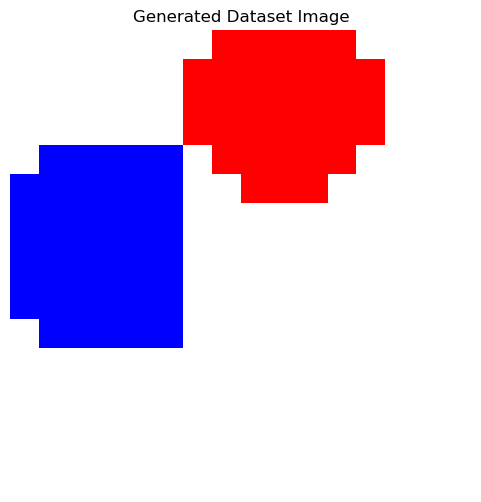

In [147]:
import matplotlib.pyplot as plt
import cv2

# Load an example image from the generated dataset
image_path = "./shapes_dataset_16x16/dataset/images/shapes_10.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Dataset Image")
plt.show()

# Load and Inspect COCO Annotations

In [150]:
import json

# Select the dataset size to check
dataset_size = "16x16"  # Change to 128x128, 28x28, or 256x256

# Define annotation file path
annotation_file = f"./shapes_dataset_{dataset_size}/dataset/annotations/shapes_coco.json"

# Load and inspect annotations
with open(annotation_file, "r") as f:
    coco_data = json.load(f)

print(f"\n✅ Loaded {annotation_file}")
print(f" - Total Images: {len(coco_data['images'])}")
print(f" - Total Annotations: {len(coco_data['annotations'])}")

# Show first 2 annotations for verification
print("\n🔍 Sample Annotation:")
print(json.dumps(coco_data["annotations"][:2], indent=4))


✅ Loaded ./shapes_dataset_16x16/dataset/annotations/shapes_coco.json
 - Total Images: 100
 - Total Annotations: 300

🔍 Sample Annotation:
[
    {
        "id": 1,
        "image_id": 0,
        "category_id": 2,
        "segmentation": [
            [
                0.25,
                0.5625,
                0.5,
                0.5625,
                0.5,
                0.8125,
                0.25,
                0.8125
            ]
        ],
        "area": 16,
        "bbox": [
            4,
            9,
            4,
            4
        ],
        "iscrowd": 0
    },
    {
        "id": 2,
        "image_id": 0,
        "category_id": 2,
        "segmentation": [
            [
                0.4375,
                0.5,
                0.6875,
                0.5,
                0.6875,
                0.75,
                0.4375,
                0.75
            ]
        ],
        "area": 16,
        "bbox": [
            7,
            8,
            4,
    

# Visualizing Segmentation Masks on Sample Image

✅ Found 3 annotations.


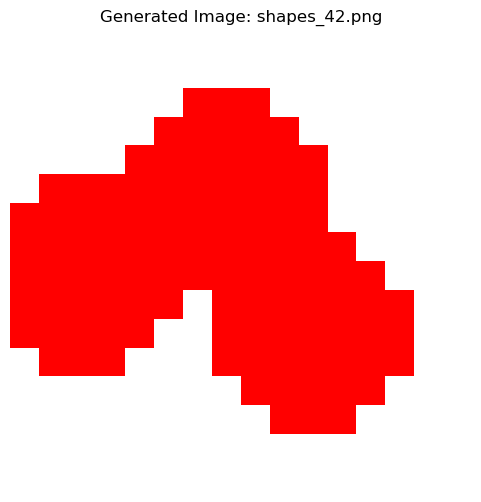

In [153]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random

# Select a random image
image_info = random.choice(coco_data["images"])
image_filename = image_info["file_name"]
image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

# Load the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the selected image
image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]

# Debugging: Ensure annotations exist
print(f"✅ Found {len(image_annotations)} annotations." if image_annotations else "❌ No annotations found!")

# Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Generated Image: {image_filename}")

# Overlay segmentation masks
for ann in image_annotations:
    segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)  # Reshape into (N, 2)

    # Ensure integer values for plotting
    plt.fill(segmentation[:, 0].astype(int), segmentation[:, 1].astype(int), color="red", alpha=0.4)

plt.show()

# Load COCO Annotations & Visualize Random Image with Segmentation

#### Load, Display, and Overlay Segmentation Masks


🔍 Sample Annotation:
[
    {
        "id": 1,
        "image_id": 0,
        "category_id": 2,
        "segmentation": [
            [
                0.25,
                0.5625,
                0.5,
                0.5625,
                0.5,
                0.8125,
                0.25,
                0.8125
            ]
        ],
        "area": 16,
        "bbox": [
            4,
            9,
            4,
            4
        ],
        "iscrowd": 0
    },
    {
        "id": 2,
        "image_id": 0,
        "category_id": 2,
        "segmentation": [
            [
                0.4375,
                0.5,
                0.6875,
                0.5,
                0.6875,
                0.75,
                0.4375,
                0.75
            ]
        ],
        "area": 16,
        "bbox": [
            7,
            8,
            4,
            4
        ],
        "iscrowd": 0
    },
    {
        "id": 3,
        "image_id": 0,
        "category_id":

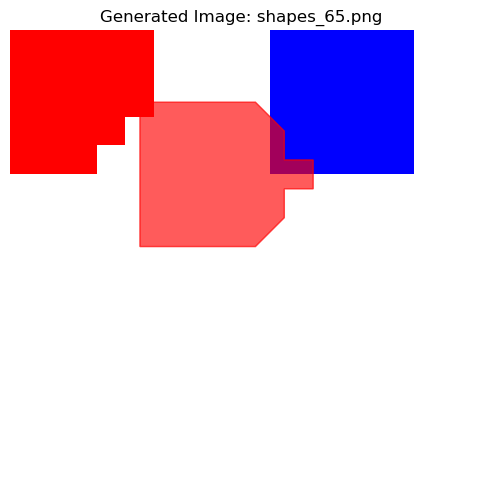

In [157]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import numpy as np
import json
import random
import os

# Choose dataset size
dataset_size = "16x16"  # Change to other resolutions as needed

# Define paths
images_dir = f"./shapes_dataset_{dataset_size}/dataset/images"
annotations_file = f"./shapes_dataset_{dataset_size}/dataset/annotations/shapes_coco.json"

# ✅ Load COCO annotation data
with open(annotations_file, "r") as f:
    coco_data = json.load(f)

# ✅ Print first 5 annotations for debugging
print("\n🔍 Sample Annotation:")
print(json.dumps(coco_data["annotations"][:5], indent=4))  # Check first 5 entries

# Pick a random image
image_info = random.choice(coco_data["images"])
image_filename = image_info["file_name"]
image_path = os.path.join(images_dir, image_filename)

# Load the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the selected image
image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]

# Plot the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Generated Image: {image_filename}")

# Overlay segmentation masks
for ann in image_annotations:
    segmentation_pd = pd.DataFrame(np.array(ann["segmentation"][0]))
    segmntation = np.array(ann["segmentation"][0])
    print(f"segmentation: {segmentation_pd.head(2)}")

    # Reshape to Nx2 format
    segmentation = segmentation.reshape(-1, 2)

    # Check if segmentation is normalized (0-1) and scale properly
    if np.max(segmentation) <= 1.0:
        print("⚠️ Scaling normalized segmentation to pixel coordinates...")
        segmentation *= np.array([image.shape[1], image.shape[0]])

    # ✅ Ensure segmentation stays within image bounds
    #segmentation['num_1_zscore'] = zscore(segmentation['num_1'])
    segmentation[:, 0] = np.clip(segmentation[:, 0], 0, image.shape[1] - 1)
    segmentation[:, 1] = np.clip(segmentation[:, 1], 0, image.shape[0] - 1)
    

    # Convert to int
    segmentation = segmentation.astype(np.int32)

    # Overlay segmentation in red
    plt.fill(segmentation[:, 0], segmentation[:, 1], color="red", alpha=0.4)

plt.show()

## Load Model

#### Set Up Torch Device for Model Execution

In [161]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

#### Load SAM Model from Checkpoint

In [164]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

#### Initialize SAM Mask Generator

In [168]:
mask_generator = SamAutomaticMaskGenerator(sam)

#### Select a Random Image from the 16x16 Dataset for Testing

In [183]:
import os
import random

# Correct dataset path
dataset_size = "16x16"
IMAGES_DIRECTORY_PATH = f"/Users/ma/Documents/samThesis/segment-anything/notebooks/shapes/shapes_dataset_{dataset_size}/dataset/images"

# Ensure directory exists before selecting an image
if os.path.exists(IMAGES_DIRECTORY_PATH) and os.listdir(IMAGES_DIRECTORY_PATH):
    IMAGE_NAME = random.choice(os.listdir(IMAGES_DIRECTORY_PATH))
    IMAGE_PATH = os.path.join(IMAGES_DIRECTORY_PATH, IMAGE_NAME)
    print(f"✅ Using Image: {IMAGE_PATH}")
else:
    print(f"❌ ERROR: No images found in {IMAGES_DIRECTORY_PATH}")

✅ Using Image: /Users/ma/Documents/samThesis/segment-anything/notebooks/shapes/shapes_dataset_16x16/dataset/images/shapes_68.png


### Generate masks with SAM

#### import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Ground Truth Mask
plt.subplot(1, 2, 1)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

# Plot Predicted Mask
plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show() 

# single-run segmentation evaluation.

#### Generate Segmentation Masks and Compare with Ground Truth

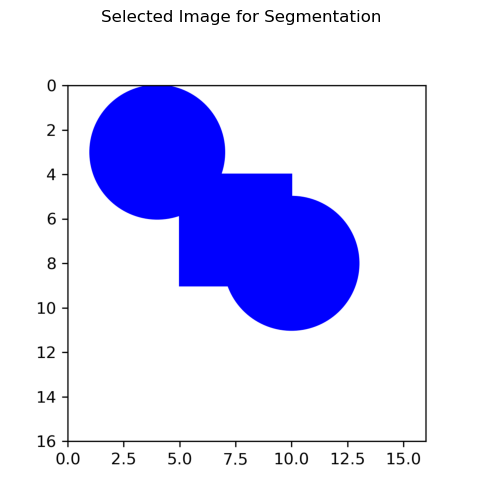

🖼️ Input Image Shape Before SAM: (1200, 1200, 3)
✅ Total detected masks: 22
✅ GT Mask Resized Shape: torch.Size([16, 16])
⚠️ Resizing predicted_mask from torch.Size([1200, 1200]) to (16, 16)
✅ Predicted Mask Resized Shape: torch.Size([16, 16])
🔹 IoU: 0.0299, Dice Score: 0.0580


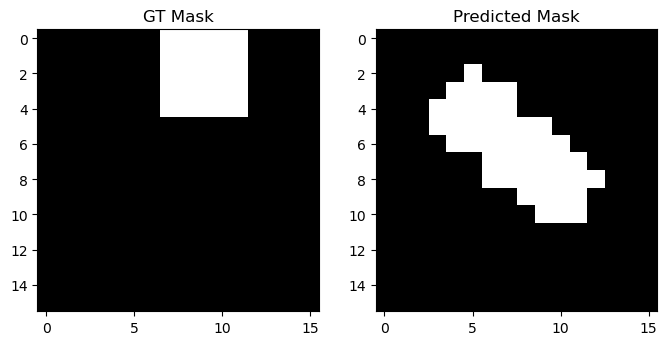

In [197]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Toggle debugging prints
DEBUG = False  # Set to True to enable detailed debugging

# Load the selected image
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the selected image before segmentation
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Selected Image for Segmentation")
plt.axis("off")
plt.show()

print(f"🖼️ Input Image Shape Before SAM: {image_rgb.shape}")

# Generate segmentation masks using SAM
sam_result = mask_generator.generate(image_rgb)

print(f"✅ Total detected masks: {len(sam_result)}")

# Extract the predicted mask (assuming first mask)
predicted_mask = sam_result[0]['segmentation']
predicted_mask = torch.tensor(predicted_mask).bool()

# Load the ground truth mask from COCO annotations
gt_mask = None
for ann in coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        # Extract segmentation points
        segmentation = np.array(ann["segmentation"][0])

        if DEBUG:
            print(f"🔍 Original Segmentation Shape: {segmentation.shape}, Values: {segmentation[:8]}")

        # Ensure segmentation has an even number of coordinates (x, y pairs)
        if len(segmentation) % 2 != 0:
            raise ValueError("Segmentation mask does not have an even number of coordinates!")

        # Reshape into (N,2) format
        segmentation = segmentation.reshape(-1, 2)

        # Scale segmentation to pixel coordinates if it's normalized
        if np.max(segmentation) <= 1.0:
            if DEBUG:
                print("⚠️ Detected normalized COCO annotations, scaling to pixel coordinates...")
            segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale up

        # Convert to int for OpenCV
        segmentation = segmentation.astype(np.int32)

        # Fill the polygon to create the mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)

        # Convert to tensor
        gt_mask = torch.tensor(gt_mask).bool()
        break

# Ensure ground truth mask exists
if gt_mask is not None:
    if DEBUG:
        print(f"⚠️ GT Mask Original Shape: {gt_mask.shape}")

    # Resize gt_mask to match 16x16 if needed
    if gt_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing gt_mask from {gt_mask.shape} to (16, 16)")
        gt_mask = F.interpolate(gt_mask.unsqueeze(0).unsqueeze(0).float(), 
                                size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()
    
    print(f"✅ GT Mask Resized Shape: {gt_mask.shape}")

    # Ensure predicted mask is also 16x16
    if predicted_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing predicted_mask from {predicted_mask.shape} to (16, 16)")
        predicted_mask = F.interpolate(predicted_mask.unsqueeze(0).unsqueeze(0).float(), 
                                       size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()

    print(f"✅ Predicted Mask Resized Shape: {predicted_mask.shape}")

    # Compute IoU & Dice Score
    iou_score = compute_iou(predicted_mask, gt_mask)
    dice_score = compute_dice(predicted_mask, gt_mask)

    # Print the results
    print(f"🔹 IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot the masks for verification
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("GT Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()
else:
    print("❌ No ground truth mask found for this image.")

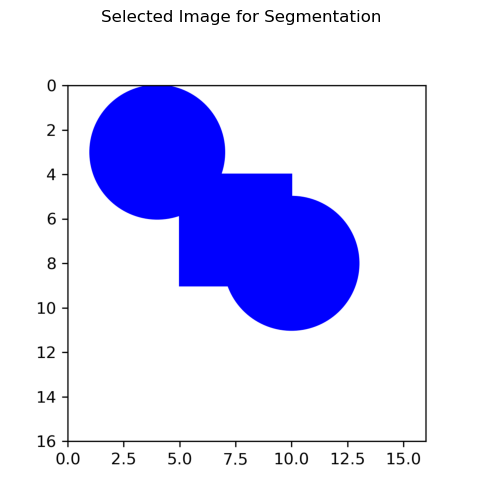

🖼️ Input Image Shape Before SAM: (1200, 1200, 3)
✅ Total detected masks: 22
✅ GT Mask Shape: torch.Size([16, 16])
✅ Predicted Mask Shape: torch.Size([1200, 1200])


RuntimeError: The size of tensor a (1200) must match the size of tensor b (16) at non-singleton dimension 1

In [189]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Toggle debugging prints
DEBUG = False  # Set to True to enable detailed debugging

# Load the selected image
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the selected image before segmentation
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Selected Image for Segmentation")
plt.axis("off")
plt.show()

print(f"🖼️ Input Image Shape Before SAM: {image_rgb.shape}")

# Generate segmentation masks using SAM
sam_result = mask_generator.generate(image_rgb)

print(f"✅ Total detected masks: {len(sam_result)}")

# Extract the predicted mask (assuming first mask)
predicted_mask = sam_result[0]['segmentation']
predicted_mask = torch.tensor(predicted_mask).bool()

# Load the ground truth mask from COCO annotations
gt_mask = None
for ann in coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        # Extract segmentation points
        segmentation = np.array(ann["segmentation"][0])

        if DEBUG:
            print(f"🔍 Original Segmentation Shape: {segmentation.shape}, Values: {segmentation[:8]}")

        # Ensure segmentation has an even number of coordinates (x, y pairs)
        if len(segmentation) % 2 != 0:
            raise ValueError("Segmentation mask does not have an even number of coordinates!")

        # Reshape into (N,2) format
        segmentation = segmentation.reshape(-1, 2)

        # Scale segmentation to pixel coordinates if it's normalized
        if np.max(segmentation) <= 1.0:
            if DEBUG:
                print("⚠️ Detected normalized COCO annotations, scaling to pixel coordinates...")
            segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale up

        # Convert to int for OpenCV
        segmentation = segmentation.astype(np.int32)

        # Fill the polygon to create the mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)

        # Convert to tensor
        gt_mask = torch.tensor(gt_mask).bool()
        break

# Ensure ground truth mask exists
if gt_mask is not None:
    print(f"✅ GT Mask Shape: {gt_mask.shape}")  # It should already be (16,16)

    # Ensure predicted mask is also 16x16 (No resizing applied)
    print(f"✅ Predicted Mask Shape: {predicted_mask.shape}")

    # Compute IoU & Dice Score
    iou_score = compute_iou(predicted_mask, gt_mask)
    dice_score = compute_dice(predicted_mask, gt_mask)

    # Print the results
    print(f"🔹 IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot the masks for verification
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("GT Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()
else:
    print("❌ No ground truth mask found for this image.")

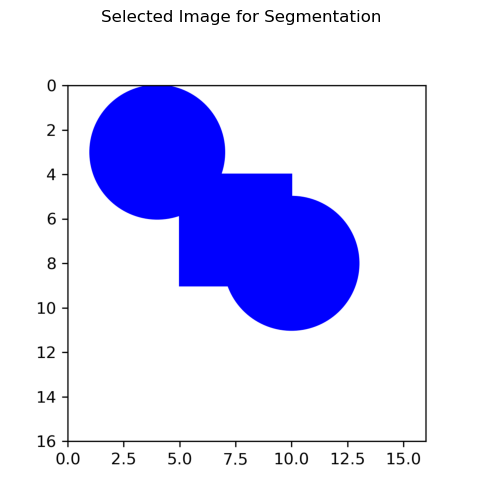

🖼️ Input Image Shape Before SAM: (1200, 1200, 3)
✅ Total detected masks: 22
✅ GT Mask Shape: torch.Size([16, 16])
⚠️ Resizing predicted_mask from torch.Size([1200, 1200]) to (16, 16)
✅ Predicted Mask Resized Shape: torch.Size([16, 16])
🔹 IoU: 0.0000, Dice Score: 0.0000


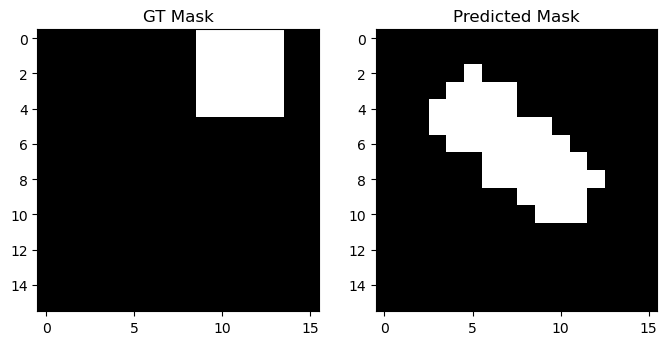

In [191]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Toggle debugging prints
DEBUG = False  # Set to True to enable detailed debugging

# Load the selected image
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the selected image before segmentation
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Selected Image for Segmentation")
plt.axis("off")
plt.show()

print(f"🖼️ Input Image Shape Before SAM: {image_rgb.shape}")

# Generate segmentation masks using SAM
sam_result = mask_generator.generate(image_rgb)

print(f"✅ Total detected masks: {len(sam_result)}")

# Extract the predicted mask (assuming first mask)
predicted_mask = sam_result[0]['segmentation']
predicted_mask = torch.tensor(predicted_mask).bool()

# Load the ground truth mask from COCO annotations
gt_mask = None
for ann in coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        # Extract segmentation points
        segmentation = np.array(ann["segmentation"][0])

        if DEBUG:
            print(f"🔍 Original Segmentation Shape: {segmentation.shape}, Values: {segmentation[:8]}")

        # Ensure segmentation has an even number of coordinates (x, y pairs)
        if len(segmentation) % 2 != 0:
            raise ValueError("Segmentation mask does not have an even number of coordinates!")

        # Reshape into (N,2) format
        segmentation = segmentation.reshape(-1, 2)

        # Scale segmentation to pixel coordinates if it's normalized
        if np.max(segmentation) <= 1.0:
            if DEBUG:
                print("⚠️ Detected normalized COCO annotations, scaling to pixel coordinates...")
            segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale up

        # Convert to int for OpenCV
        segmentation = segmentation.astype(np.int32)

        # Fill the polygon to create the mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)

        # Convert to tensor
        gt_mask = torch.tensor(gt_mask).bool()
        break

# Ensure ground truth mask exists
if gt_mask is not None:
    print(f"✅ GT Mask Shape: {gt_mask.shape}")  # Should be (16,16)

    # 🔴 **Fix: Resize Predicted Mask to Match GT Mask (16x16)**
    if predicted_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing predicted_mask from {predicted_mask.shape} to (16, 16)")
        predicted_mask = F.interpolate(predicted_mask.unsqueeze(0).unsqueeze(0).float(), 
                                       size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()

    print(f"✅ Predicted Mask Resized Shape: {predicted_mask.shape}")

    # Compute IoU & Dice Score
    iou_score = compute_iou(predicted_mask, gt_mask)
    dice_score = compute_dice(predicted_mask, gt_mask)

    # Print the results
    print(f"🔹 IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot the masks for verification
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("GT Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()
else:
    print("❌ No ground truth mask found for this image.")

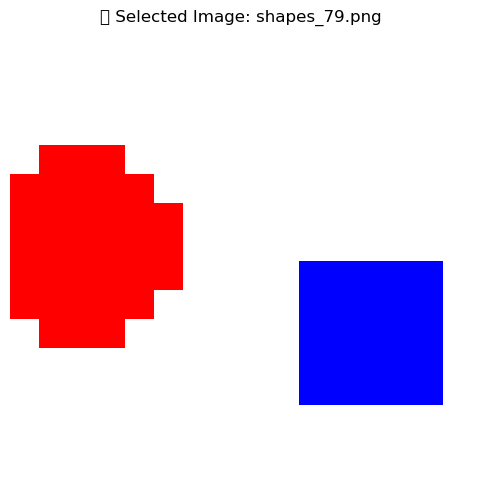

🖼️ Input Image Shape Before SAM: (16, 16, 3)
🔍 Original Segmentation Shape: (8,)
🔍 Original Segmentation Shape: (40,)
✅ GT Mask Shape: torch.Size([16, 16])
✅ Total detected masks: 33
✅ GT Mask Shape: torch.Size([16, 16])
✅ Predicted Mask Shape: torch.Size([16, 16])
🔹 IoU: 0.4833, Dice Score: 0.6517


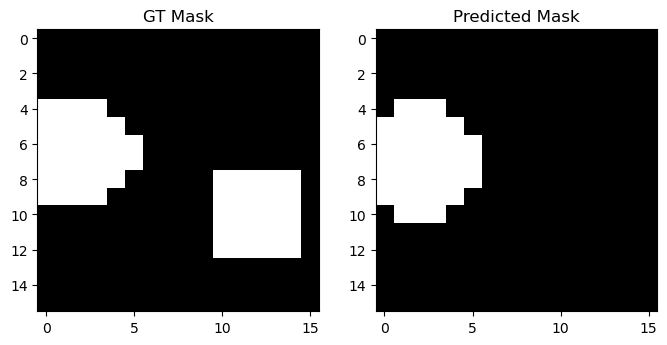

In [193]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import random
import json
import os

# Toggle debugging prints
DEBUG = True  # Set to False to disable debugging

# Load COCO dataset annotations
dataset_size = "16x16"
annotation_file = f"./shapes_dataset_{dataset_size}/dataset/annotations/shapes_coco.json"

with open(annotation_file, "r") as f:
    coco_data = json.load(f)

# Select a random image
image_info = random.choice(coco_data["images"])
image_filename = image_info["file_name"]
image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

# Load the image
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the selected image
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title(f"🖼️ Selected Image: {image_filename}")
plt.axis("off")
plt.show()

print(f"🖼️ Input Image Shape Before SAM: {image_rgb.shape}")

# Get annotations for the selected image
image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]

if len(image_annotations) == 0:
    print("❌ No annotations found for this image.")

# Initialize GT Mask
gt_mask = np.zeros((image_rgb.shape[0], image_rgb.shape[1]), dtype=np.uint8)

for ann in image_annotations:
    segmentation = np.array(ann["segmentation"][0])

    if DEBUG:
        print(f"🔍 Original Segmentation Shape: {segmentation.shape}")

    # Reshape into (N,2) format
    segmentation = segmentation.reshape(-1, 2)

    # Convert normalized segmentation to pixel coordinates
    segmentation *= np.array([image_rgb.shape[1], image_rgb.shape[0]])
    segmentation = segmentation.astype(np.int32)

    # Fill the GT mask
    cv2.fillPoly(gt_mask, [segmentation], color=1)

# Convert GT mask to tensor
gt_mask = torch.tensor(gt_mask).bool()

# Ensure GT mask is 16x16
if gt_mask.shape[-2:] != (16, 16):
    gt_mask = F.interpolate(gt_mask.unsqueeze(0).unsqueeze(0).float(),
                            size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()

print(f"✅ GT Mask Shape: {gt_mask.shape}")

# Generate segmentation masks using SAM
sam_result = mask_generator.generate(image_rgb)

print(f"✅ Total detected masks: {len(sam_result)}")

# Select the best predicted mask (IoU-based)
best_iou = 0
best_mask = None

for mask in sam_result:
    temp_mask = torch.tensor(mask['segmentation']).bool()

    # Resize predicted mask to match 16x16
    if temp_mask.shape[-2:] != (16, 16):
        temp_mask = F.interpolate(temp_mask.unsqueeze(0).unsqueeze(0).float(), 
                                  size=(16, 16), mode="nearest").squeeze(0).squeeze(0).bool()

    # Compute IoU for this mask
    temp_iou = compute_iou(temp_mask, gt_mask)

    # Keep the best mask
    if temp_iou > best_iou:
        best_iou = temp_iou
        best_mask = temp_mask

# Use the best mask for final IoU/Dice calculations
predicted_mask = best_mask if best_mask is not None else torch.zeros_like(gt_mask)

print(f"✅ GT Mask Shape: {gt_mask.shape}")
print(f"✅ Predicted Mask Shape: {predicted_mask.shape}")

# Compute IoU & Dice Score
iou_score = compute_iou(predicted_mask, gt_mask)
dice_score = compute_dice(predicted_mask, gt_mask)

# Print the results
print(f"🔹 IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

# Plot the masks for verification
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
plt.title("GT Mask")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
plt.title("Predicted Mask")

plt.show()

#### Inspect SAM Output Keys for Further Processing

In [80]:
import os
import cv2

# Define the dataset path
dataset_size = "16x16"  # Change if needed
images_dir = f"./shapes_dataset_{dataset_size}/dataset/images"

# List all images
image_files = os.listdir(images_dir)

# Load and check the first few images
for image_file in image_files[:5]:  # Checking first 5 images
    image_path = os.path.join(images_dir, image_file)
    image = cv2.imread(image_path)
    
    if image is not None:
        print(f"🖼️ Image: {image_file} | Shape: {image.shape}")
    else:
        print(f"⚠️ Could not load {image_file}")



🖼️ Image: shapes_43.png | Shape: (16, 16, 3)
🖼️ Image: shapes_57.png | Shape: (16, 16, 3)
🖼️ Image: shapes_7.png | Shape: (16, 16, 3)
🖼️ Image: shapes_80.png | Shape: (16, 16, 3)
🖼️ Image: shapes_94.png | Shape: (16, 16, 3)


In [82]:
print("SAM Result Keys:", list(sam_result[0].keys()))

SAM Result Keys: ['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box']


#### Overlay Ground Truth & Predicted Masks for Comparison

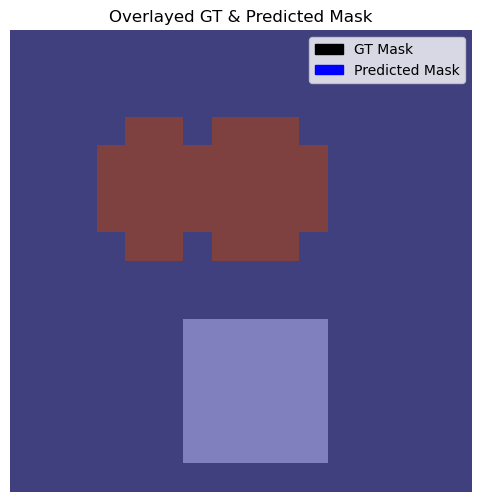

In [85]:
# Overlay Ground Truth & Predicted Masks for Comparison
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(6, 6))

# Display GT mask in grayscale
plt.imshow(gt_mask.cpu().numpy(), cmap="gray", alpha=0.5)

# Display predicted mask in jet colormap
plt.imshow(predicted_mask.cpu().numpy(), cmap="jet", alpha=0.5)

# Add a manual legend
legend_patches = [
    Patch(color="black", label="GT Mask"), 
    Patch(color="blue", label="Predicted Mask")
]
plt.legend(handles=legend_patches, loc="upper right")

plt.title("Overlayed GT & Predicted Mask")
plt.axis("off")
plt.show()

### Output format

`SamAutomaticMaskGenerator` returns a `list` of masks, where each mask is a `dict` containing various information about the mask:

* `segmentation` - `[np.ndarray]` - the mask with `(W, H)` shape, and `bool` type
* `area` - `[int]` - the area of the mask in pixels
* `bbox` - `[List[int]]` - the boundary box of the mask in `xywh` format
* `predicted_iou` - `[float]` - the model's own prediction for the quality of the mask
* `point_coords` - `[List[List[float]]]` - the sampled input point that generated this mask
* `stability_score` - `[float]` - an additional measure of mask quality
* `crop_box` - `List[int]` - the crop of the image used to generate this mask in `xywh` format

### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

#### Annotate and Visualize Segmentation Masks

✅ Total detected masks: 21


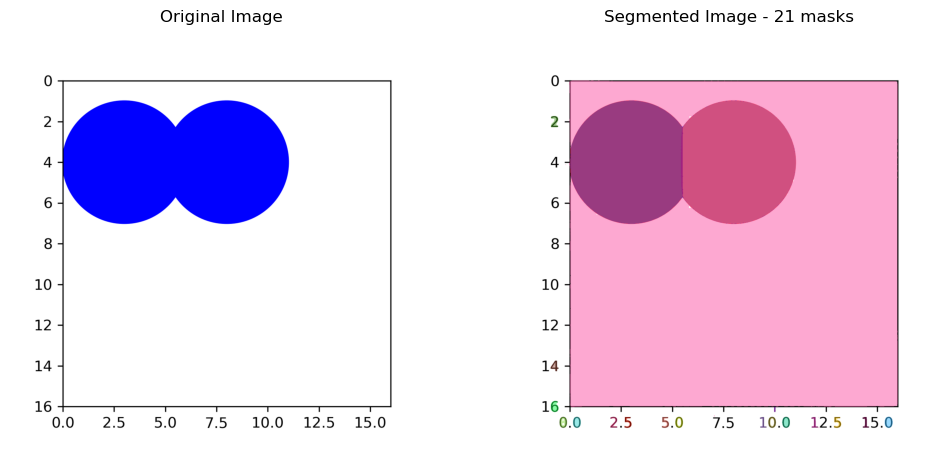

In [91]:
import supervision as sv
import matplotlib.pyplot as plt

print(f"✅ Total detected masks: {len(sam_result)}")

# Create a mask annotator
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

# Convert SAM output to supervision-compatible format
detections = sv.Detections.from_sam(sam_result=sam_result)  # Use all masks, no filtering

# Annotate the image with segmentation masks
annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

# Display original and segmented images side by side
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

# Segmented Image
plt.subplot(1, 2, 2)
plt.imshow(annotated_image)
plt.title(f"Segmented Image - {len(sam_result)} masks")
plt.axis("off")

plt.show()


### Interaction with segmentation results

#### Display All Generated Masks in a Grid

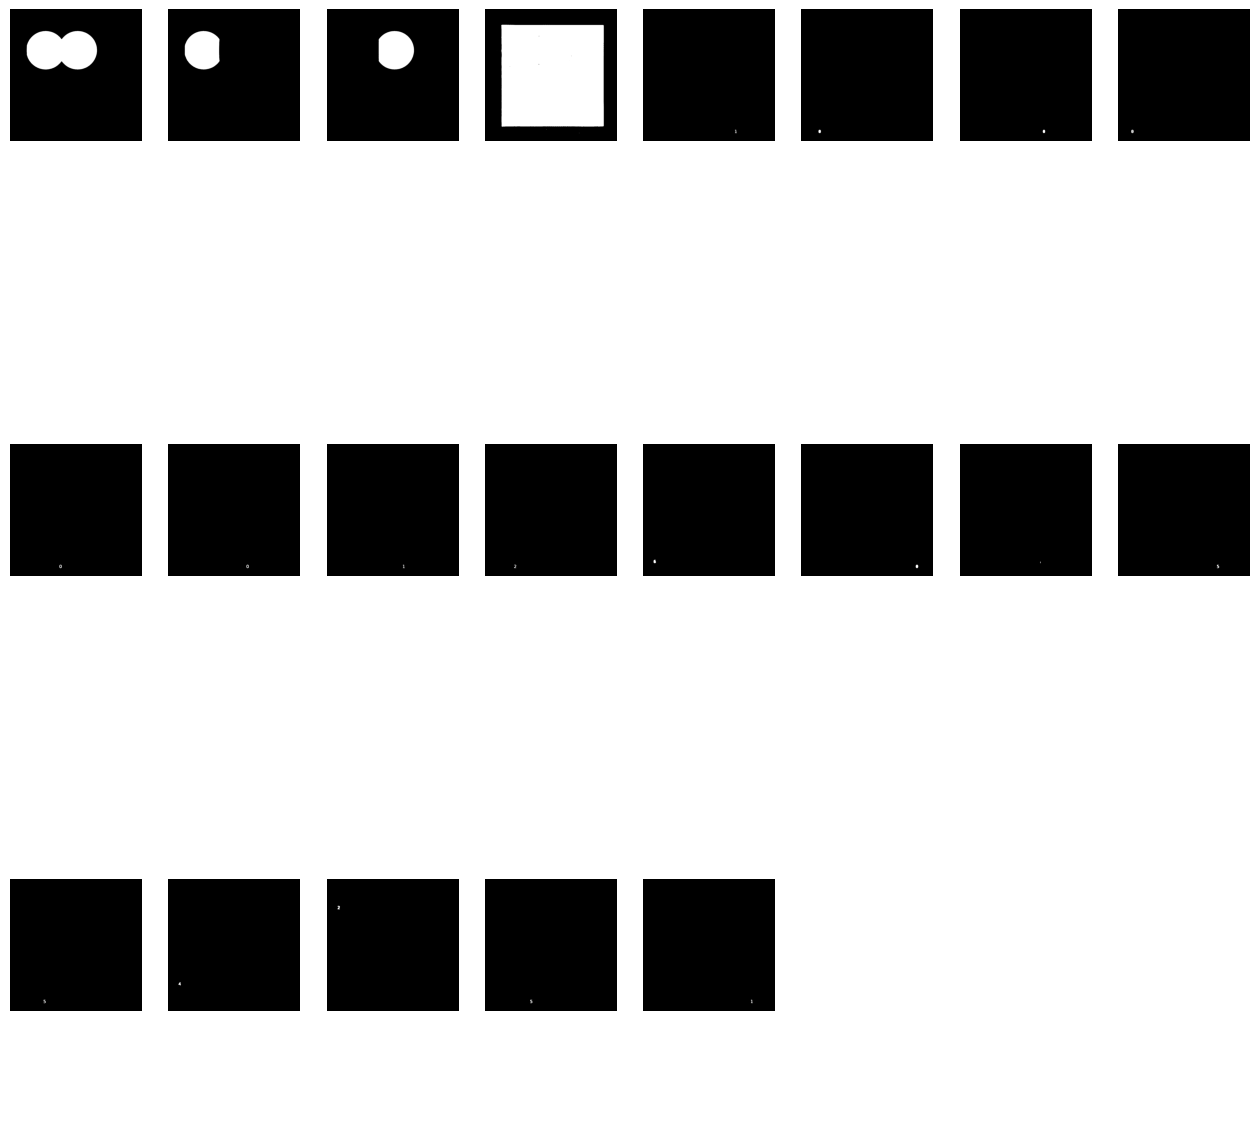

In [95]:
# Show all masks without filtering
masks = [mask['segmentation'] for mask in sam_result]

# Calculate grid size dynamically
num_masks = len(masks)
grid_cols = min(8, num_masks)  # Limit columns to a max of 8
grid_rows = (num_masks // grid_cols) + (num_masks % grid_cols > 0)  # Ensure all images fit

# Display masks in a properly sized grid
sv.plot_images_grid(
    images=masks,
    grid_size=(grid_rows, grid_cols),  # Auto-adjusted grid size
    size=(16, 16)
)

## Generate Segmentation with Bounding Box

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

In [98]:
mask_predictor = SamPredictor(sam)

#### Load and Verify Dataset Image Files

In [101]:
import os
import random

# Verify the images directory exists
if not os.path.exists(IMAGES_DIRECTORY_PATH):
    raise FileNotFoundError(f"❌ The specified images directory does not exist: {IMAGES_DIRECTORY_PATH}")
else:
    # Load image filenames
    IMAGES = os.listdir(IMAGES_DIRECTORY_PATH)

    if len(IMAGES) == 0:
        print("❌ ERROR: No images found in the dataset folder.")
    else:
        # Pick a random image
        IMAGE_NAME = random.choice(IMAGES)
        IMAGE_PATH = os.path.join(IMAGES_DIRECTORY_PATH, IMAGE_NAME)

        print(f"✅ Using Image: {IMAGE_PATH}")

✅ Using Image: /Users/ma/Documents/samThesis/segment-anything/notebooks/shapes/shapes_dataset_16x16/dataset/images/shapes_83.png


# epochs-based segmentation experiment


🚀 Epoch 1/5 running...

🖼️ Input Image: shapes_64.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 23
✅ Predicted Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Final Shape: torch.Size([16, 16])
✅ Predicted Mask Final Shape: torch.Size([16, 16])
🔍 IoU Calculation - Pred Mask Shape: torch.Size([16, 16]), GT Mask Shape: torch.Size([16, 16])
🔍 Overlapping Pixels: 35, Union Pixels: 256
🔍 Dice Calculation - Intersection: 35, Total Pixels in Both Masks: 291
🔹 Epoch 1 - IoU: 0.1367, Dice Score: 0.2405


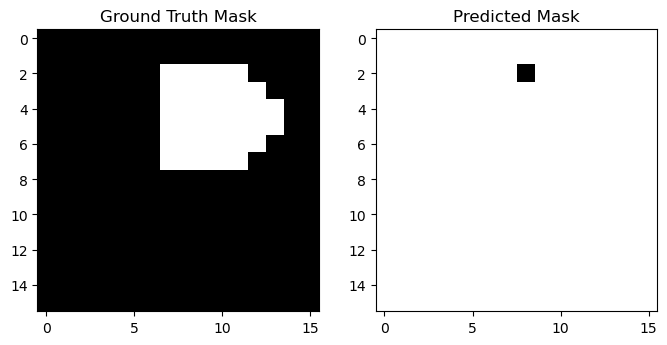


🚀 Epoch 2/5 running...

🖼️ Input Image: shapes_48.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 12
✅ Predicted Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Final Shape: torch.Size([16, 16])
✅ Predicted Mask Final Shape: torch.Size([16, 16])
🔍 IoU Calculation - Pred Mask Shape: torch.Size([16, 16]), GT Mask Shape: torch.Size([16, 16])
🔍 Overlapping Pixels: 25, Union Pixels: 256
🔍 Dice Calculation - Intersection: 25, Total Pixels in Both Masks: 281
🔹 Epoch 2 - IoU: 0.0977, Dice Score: 0.1779


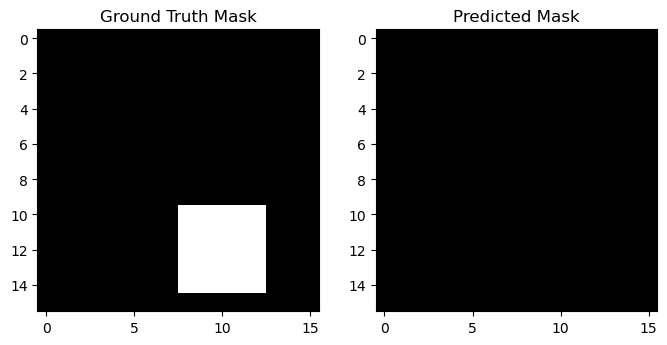


🚀 Epoch 3/5 running...

🖼️ Input Image: shapes_4.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 5
✅ Predicted Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Final Shape: torch.Size([16, 16])
✅ Predicted Mask Final Shape: torch.Size([16, 16])
🔍 IoU Calculation - Pred Mask Shape: torch.Size([16, 16]), GT Mask Shape: torch.Size([16, 16])
🔍 Overlapping Pixels: 25, Union Pixels: 256
🔍 Dice Calculation - Intersection: 25, Total Pixels in Both Masks: 281
🔹 Epoch 3 - IoU: 0.0977, Dice Score: 0.1779


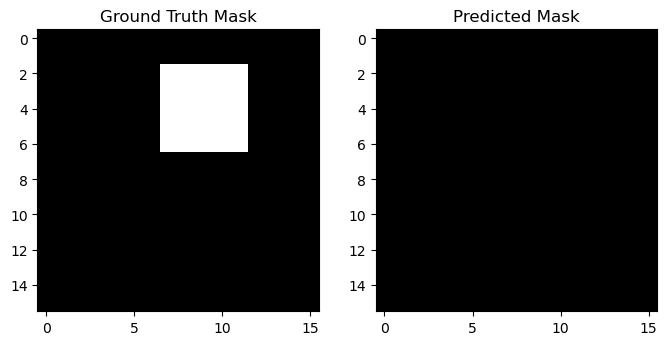


🚀 Epoch 4/5 running...

🖼️ Input Image: shapes_89.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 32
✅ Predicted Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Final Shape: torch.Size([16, 16])
✅ Predicted Mask Final Shape: torch.Size([16, 16])
🔍 IoU Calculation - Pred Mask Shape: torch.Size([16, 16]), GT Mask Shape: torch.Size([16, 16])
🔍 Overlapping Pixels: 25, Union Pixels: 256
🔍 Dice Calculation - Intersection: 25, Total Pixels in Both Masks: 281
🔹 Epoch 4 - IoU: 0.0977, Dice Score: 0.1779


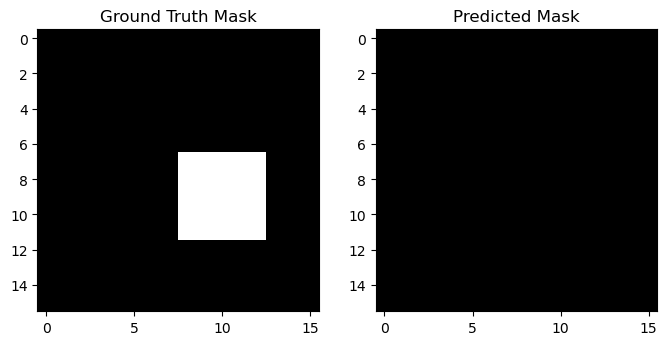


🚀 Epoch 5/5 running...

🖼️ Input Image: shapes_44.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 12
✅ Predicted Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
✅ GT Mask Final Shape: torch.Size([16, 16])
✅ Predicted Mask Final Shape: torch.Size([16, 16])
🔍 IoU Calculation - Pred Mask Shape: torch.Size([16, 16]), GT Mask Shape: torch.Size([16, 16])
🔍 Overlapping Pixels: 25, Union Pixels: 256
🔍 Dice Calculation - Intersection: 25, Total Pixels in Both Masks: 281
🔹 Epoch 5 - IoU: 0.0977, Dice Score: 0.1779


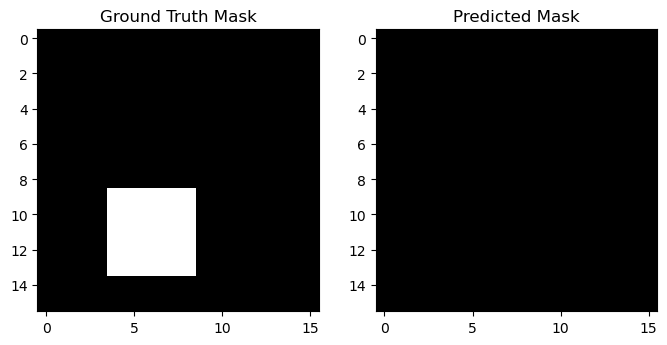


📊 **Epoch Results Summary**
Epoch 1: shapes_64.png -> IoU: 0.1367, Dice: 0.2405
Epoch 2: shapes_48.png -> IoU: 0.0977, Dice: 0.1779
Epoch 3: shapes_4.png -> IoU: 0.0977, Dice: 0.1779
Epoch 4: shapes_89.png -> IoU: 0.0977, Dice: 0.1779
Epoch 5: shapes_44.png -> IoU: 0.0977, Dice: 0.1779


In [207]:
import torch
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Define number of epochs
NUM_EPOCHS = 5  # Change as needed

# Store results for each epoch
epoch_results = []

# Loop over multiple epochs
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...\n")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    print(f"🖼️ Input Image: {image_filename} | Shape Before SAM: {image.shape}")

    # Get annotations
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM to generate segmentation masks
    sam_result = mask_generator.generate(image)

    print(f"✅ Total detected masks: {len(sam_result)}")

    # Extract the first predicted mask
    #predicted_mask = sam_result[0]['segmentation']
    #predicted_mask = torch.tensor(predicted_mask).bool()
    # Combine all predicted masks
    predicted_mask = np.zeros((16, 16), dtype=np.uint8)
    for mask in sam_result:
        predicted_mask = np.logical_or(predicted_mask, mask['segmentation'])
    
    # Convert to PyTorch tensor
    predicted_mask = torch.tensor(predicted_mask).bool()

    
    print(f"✅ Predicted Mask Shape Before Any Processing: {predicted_mask.shape}")

    # Load ground truth mask
    gt_mask = None
    for ann in image_annotations:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)

        # Scale segmentation if needed
        if np.max(segmentation) <= 1.0:
            segmentation *= np.array([image.shape[1], image.shape[0]])
        segmentation = segmentation.astype(np.int32)

        # Create the ground truth mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        gt_mask = torch.tensor(gt_mask).bool()
        break  # Process only one annotation per image

    print(f"✅ GT Mask Shape Before Any Processing: {gt_mask.shape}")

    # Resize ground truth mask if needed
    if gt_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing GT Mask from {gt_mask.shape} to (16, 16)")
        gt_mask = torch.nn.functional.interpolate(
            gt_mask.unsqueeze(0).unsqueeze(0).float(),
            size=(16, 16), mode="nearest"
        ).squeeze(0).squeeze(0).bool()

    # Resize predicted mask if needed
    if predicted_mask.shape[-2:] != (16, 16):
        print(f"⚠️ Resizing Predicted Mask from {predicted_mask.shape} to (16, 16)")
        predicted_mask = torch.nn.functional.interpolate(
            predicted_mask.unsqueeze(0).unsqueeze(0).float(),
            size=(16, 16), mode="nearest"
        ).squeeze(0).squeeze(0).bool()

    print(f"✅ GT Mask Final Shape: {gt_mask.shape}")
    print(f"✅ Predicted Mask Final Shape: {predicted_mask.shape}")

    # Compute IoU & Dice Scores
    iou_score = compute_iou(predicted_mask, gt_mask)
    dice_score = compute_dice(predicted_mask, gt_mask)

    # Store results
    epoch_results.append({
        "epoch": epoch,
        "image": image_filename,
        "iou": iou_score,
        "dice": dice_score
    })

    # Print metrics
    print(f"🔹 Epoch {epoch} - IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot for visualization
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("Ground Truth Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()

# Print all epoch results
print("\n📊 **Epoch Results Summary**")
for result in epoch_results:
    print(f"Epoch {result['epoch']}: {result['image']} -> IoU: {result['iou']:.4f}, Dice: {result['dice']:.4f}")


🚀 Epoch 1/5 running...

🖼️ Input Image: shapes_34.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 47
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.5625     0.625     ]
 [0.55234073 0.68588115]
 [0.52296385 0.74016488]
 [0.47755278 0.78196871]
 [0.42102853 0.80676255]
 [0.35951637 0.81185959]
 [0.29968211 0.7967075 ]
 [0.24800971 0.76294823]
 [0.21009867 0.71424014]
 [0.19005726 0.65586149]
 [0.19005726 0.59413851]
 [0.21009867 0.53575986]
 [0.24800971 0.48705177]
 [0.29968211 0.4532925 ]
 [0.35951637 0.43814041]
 [0.42102853 0.44323745]
 [0.47755278 0.46803129]
 [0.52296385 0.50983512]
 [0.55234073 0.56411885]
 [0.5625     0.625     ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 1 - IoU: 0.1367, Dice Score: 0.2405


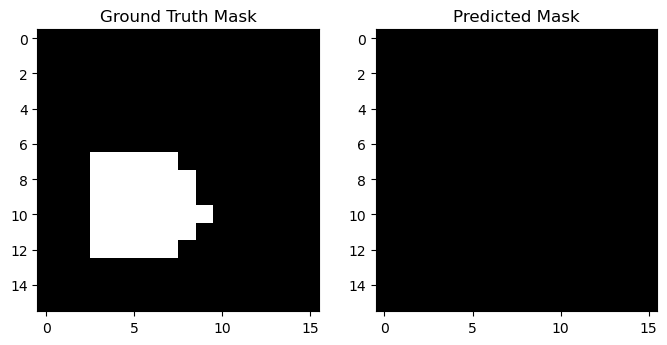


🚀 Epoch 2/5 running...

🖼️ Input Image: shapes_63.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 6
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.    0.625]
 [0.25  0.625]
 [0.25  0.875]
 [0.    0.875]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 2 - IoU: 0.0977, Dice Score: 0.1779


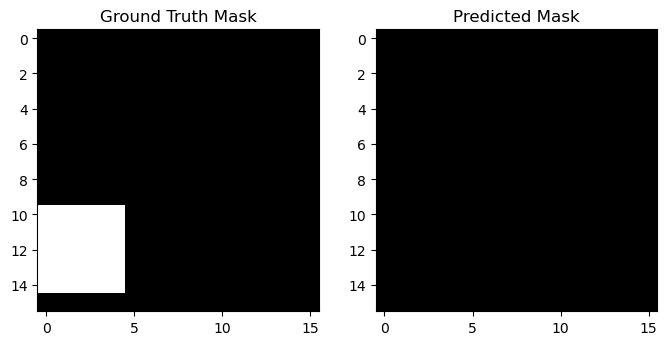


🚀 Epoch 3/5 running...

🖼️ Input Image: shapes_55.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 35
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.4375     0.4375    ]
 [0.42734073 0.49838115]
 [0.39796385 0.55266488]
 [0.35255278 0.59446871]
 [0.29602853 0.61926255]
 [0.23451637 0.62435959]
 [0.17468211 0.6092075 ]
 [0.12300971 0.57544823]
 [0.08509867 0.52674014]
 [0.06505726 0.46836149]
 [0.06505726 0.40663851]
 [0.08509867 0.34825986]
 [0.12300971 0.29955177]
 [0.17468211 0.2657925 ]
 [0.23451637 0.25064041]
 [0.29602853 0.25573745]
 [0.35255278 0.28053129]
 [0.39796385 0.32233512]
 [0.42734073 0.37661885]
 [0.4375     0.4375    ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 3 - IoU: 0.1367, Dice Score: 0.2405


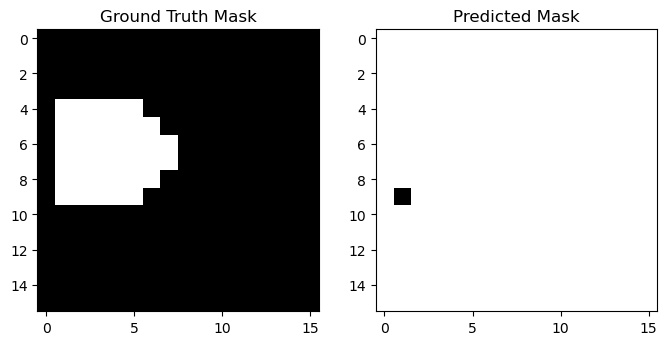


🚀 Epoch 4/5 running...

🖼️ Input Image: shapes_30.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 7
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.625  0.3125]
 [0.875  0.3125]
 [0.875  0.5625]
 [0.625  0.5625]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 4 - IoU: 0.0977, Dice Score: 0.1779


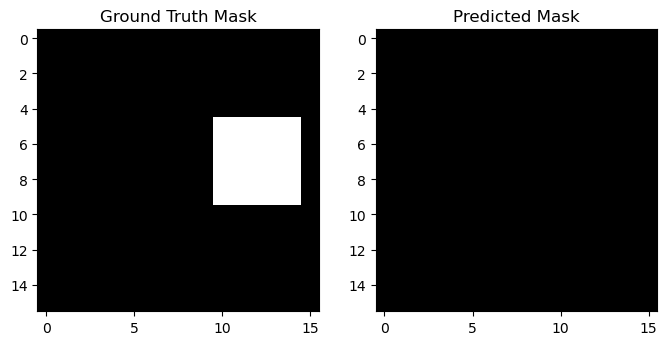


🚀 Epoch 5/5 running...

🖼️ Input Image: shapes_33.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 10
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.3125 0.625 ]
 [0.5625 0.625 ]
 [0.5625 0.875 ]
 [0.3125 0.875 ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 5 - IoU: 0.0984, Dice Score: 0.1792


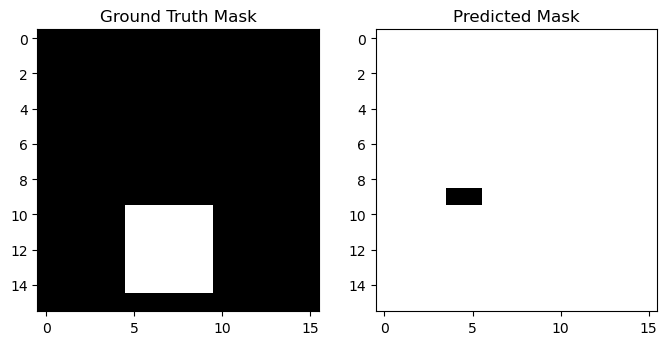


📊 **Epoch Results Summary**
Epoch 1: shapes_34.png -> IoU: 0.1367, Dice: 0.2405
Epoch 2: shapes_63.png -> IoU: 0.0977, Dice: 0.1779
Epoch 3: shapes_55.png -> IoU: 0.1367, Dice: 0.2405
Epoch 4: shapes_30.png -> IoU: 0.0977, Dice: 0.1779
Epoch 5: shapes_33.png -> IoU: 0.0984, Dice: 0.1792


In [222]:
import torch
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Define number of epochs
NUM_EPOCHS = 5  # Change as needed

# Store results for each epoch
epoch_results = []

# Loop over multiple epochs
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...\n")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    print(f"🖼️ Input Image: {image_filename} | Shape Before SAM: {image.shape}")

    # Get annotations
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM to generate segmentation masks
    sam_result = mask_generator.generate(image)

    print(f"✅ Total detected masks: {len(sam_result)}")

    # Track size of predicted mask from SAM
    first_pred_mask = sam_result[0]['segmentation']
    print(f"📏 First Predicted Mask Shape from SAM: {first_pred_mask.shape}")

    # Combine all predicted masks (logical OR across masks)
    combined_pred_mask = np.zeros_like(first_pred_mask, dtype=np.uint8)
    for mask in sam_result:
        combined_pred_mask = np.logical_or(combined_pred_mask, mask['segmentation'])

    # Convert to PyTorch tensor
    combined_pred_mask = torch.tensor(combined_pred_mask).bool()

    print(f"✅ Combined Predicted Mask Shape After Processing: {combined_pred_mask.shape}")

    # Load ground truth mask
    gt_mask = None
    for ann in image_annotations:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)

        print(f"🔍 GT Segmentation Before Any Scaling: {segmentation}")

        # Scale segmentation if needed
        if np.max(segmentation) <= 1.0:
            segmentation *= np.array([image.shape[1], image.shape[0]])

        segmentation = segmentation.astype(np.int32)

        # Create the ground truth mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        gt_mask = torch.tensor(gt_mask).bool()
        break  # Process only one annotation per image

    print(f"✅ GT Mask Shape Before Any Processing: {gt_mask.shape}")

    # Compute IoU & Dice Scores
    iou_score = compute_iou(combined_pred_mask, gt_mask)
    dice_score = compute_dice(combined_pred_mask, gt_mask)

    # Store results
    epoch_results.append({
        "epoch": epoch,
        "image": image_filename,
        "iou": iou_score,
        "dice": dice_score
    })

    # Print metrics
    print(f"🔹 Epoch {epoch} - IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot for visualization
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("Ground Truth Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(combined_pred_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask")

    plt.show()

# Print all epoch results
print("\n📊 **Epoch Results Summary**")
for result in epoch_results:
    print(f"Epoch {result['epoch']}: {result['image']} -> IoU: {result['iou']:.4f}, Dice: {result['dice']:.4f}")



🚀 Epoch 1/5 running...

🖼️ Input Image: shapes_82.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 9
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.75       0.5625    ]
 [0.73984073 0.62338115]
 [0.71046385 0.67766488]
 [0.66505278 0.71946871]
 [0.60852853 0.74426255]
 [0.54701637 0.74935959]
 [0.48718211 0.7342075 ]
 [0.43550971 0.70044823]
 [0.39759867 0.65174014]
 [0.37755726 0.59336149]
 [0.37755726 0.53163851]
 [0.39759867 0.47325986]
 [0.43550971 0.42455177]
 [0.48718211 0.3907925 ]
 [0.54701637 0.37564041]
 [0.60852853 0.38073745]
 [0.66505278 0.40553129]
 [0.71046385 0.44733512]
 [0.73984073 0.50161885]
 [0.75       0.5625    ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 1 - IoU: 0.0000, Dice Score: 0.0000


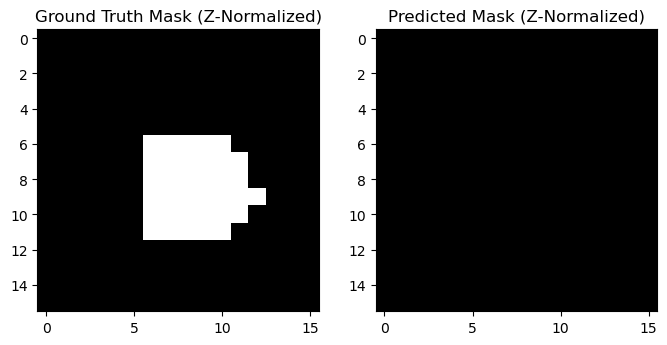


🚀 Epoch 2/5 running...

🖼️ Input Image: shapes_59.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 29
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.75       0.6875    ]
 [0.73984073 0.74838115]
 [0.71046385 0.80266488]
 [0.66505278 0.84446871]
 [0.60852853 0.86926255]
 [0.54701637 0.87435959]
 [0.48718211 0.8592075 ]
 [0.43550971 0.82544823]
 [0.39759867 0.77674014]
 [0.37755726 0.71836149]
 [0.37755726 0.65663851]
 [0.39759867 0.59825986]
 [0.43550971 0.54955177]
 [0.48718211 0.5157925 ]
 [0.54701637 0.50064041]
 [0.60852853 0.50573745]
 [0.66505278 0.53053129]
 [0.71046385 0.57233512]
 [0.73984073 0.62661885]
 [0.75       0.6875    ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 2 - IoU: 0.0000, Dice Score: 0.0000


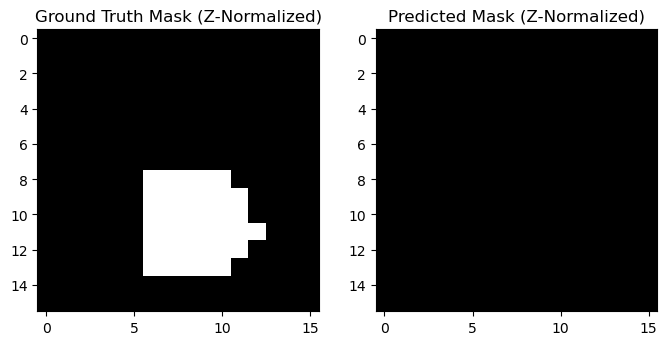


🚀 Epoch 3/5 running...

🖼️ Input Image: shapes_13.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 37
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.25   0.4375]
 [0.5    0.4375]
 [0.5    0.6875]
 [0.25   0.6875]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 3 - IoU: 1.0000, Dice Score: 1.0000


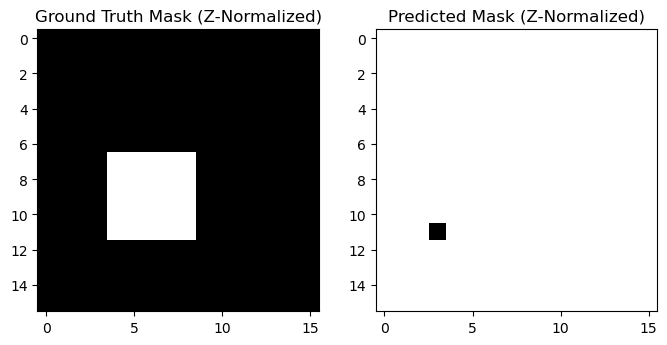


🚀 Epoch 4/5 running...

🖼️ Input Image: shapes_43.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 33
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.4375     0.625     ]
 [0.42734073 0.68588115]
 [0.39796385 0.74016488]
 [0.35255278 0.78196871]
 [0.29602853 0.80676255]
 [0.23451637 0.81185959]
 [0.17468211 0.7967075 ]
 [0.12300971 0.76294823]
 [0.08509867 0.71424014]
 [0.06505726 0.65586149]
 [0.06505726 0.59413851]
 [0.08509867 0.53575986]
 [0.12300971 0.48705177]
 [0.17468211 0.4532925 ]
 [0.23451637 0.43814041]
 [0.29602853 0.44323745]
 [0.35255278 0.46803129]
 [0.39796385 0.50983512]
 [0.42734073 0.56411885]
 [0.4375     0.625     ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 4 - IoU: 1.0000, Dice Score: 1.0000


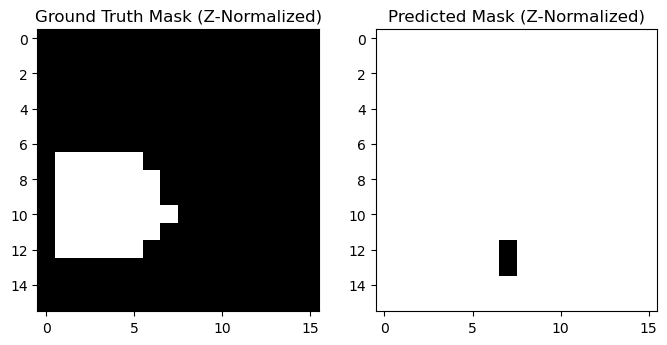


🚀 Epoch 5/5 running...

🖼️ Input Image: shapes_98.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 49
📏 First Predicted Mask Shape from SAM: (16, 16)
✅ Combined Predicted Mask Shape After Processing: torch.Size([16, 16])
🔍 GT Segmentation Before Any Scaling: [[0.375      0.25      ]
 [0.36484073 0.31088115]
 [0.33546385 0.36516488]
 [0.29005278 0.40696871]
 [0.23352853 0.43176255]
 [0.17201637 0.43685959]
 [0.11218211 0.4217075 ]
 [0.06050971 0.38794823]
 [0.02259867 0.33924014]
 [0.00255726 0.28086149]
 [0.00255726 0.21913851]
 [0.02259867 0.16075986]
 [0.06050971 0.11205177]
 [0.11218211 0.0782925 ]
 [0.17201637 0.06314041]
 [0.23352853 0.06823745]
 [0.29005278 0.09303129]
 [0.33546385 0.13483512]
 [0.36484073 0.18911885]
 [0.375      0.25      ]]
✅ GT Mask Shape Before Any Processing: torch.Size([16, 16])
🔹 Epoch 5 - IoU: 1.0000, Dice Score: 1.0000


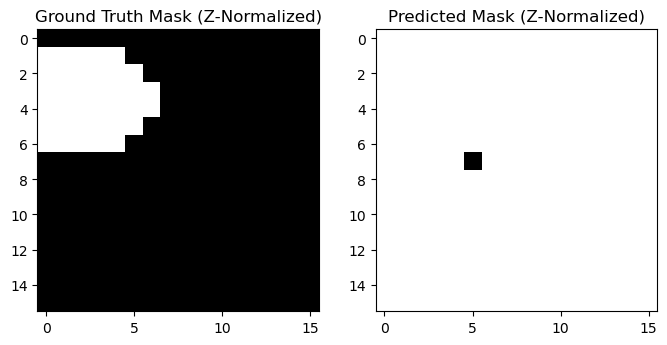


📊 **Epoch Results Summary**
Epoch 1: shapes_82.png -> IoU: 0.0000, Dice: 0.0000
Epoch 2: shapes_59.png -> IoU: 0.0000, Dice: 0.0000
Epoch 3: shapes_13.png -> IoU: 1.0000, Dice: 1.0000
Epoch 4: shapes_43.png -> IoU: 1.0000, Dice: 1.0000
Epoch 5: shapes_98.png -> IoU: 1.0000, Dice: 1.0000


In [224]:
import torch
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Function for Z-Normalization
def z_normalize(mask):
    """
    Apply Z-Normalization: (x - mean) / std
    Ensures pixel values are standardized.
    """
    mask = mask.float()
    return (mask - mask.mean()) / (mask.std() + 1e-8)

# Define number of epochs
NUM_EPOCHS = 5  # Change as needed

# Store results for each epoch
epoch_results = []

# Loop over multiple epochs
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...\n")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    print(f"🖼️ Input Image: {image_filename} | Shape Before SAM: {image.shape}")

    # Get annotations
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM to generate segmentation masks
    sam_result = mask_generator.generate(image)

    print(f"✅ Total detected masks: {len(sam_result)}")

    # Track size of predicted mask from SAM
    first_pred_mask = sam_result[0]['segmentation']
    print(f"📏 First Predicted Mask Shape from SAM: {first_pred_mask.shape}")

    # Combine all predicted masks (logical OR across masks)
    combined_pred_mask = np.zeros_like(first_pred_mask, dtype=np.uint8)
    for mask in sam_result:
        combined_pred_mask = np.logical_or(combined_pred_mask, mask['segmentation'])

    # Convert to PyTorch tensor
    combined_pred_mask = torch.tensor(combined_pred_mask).bool()

    print(f"✅ Combined Predicted Mask Shape After Processing: {combined_pred_mask.shape}")

    # Load ground truth mask
    gt_mask = None
    for ann in image_annotations:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)

        print(f"🔍 GT Segmentation Before Any Scaling: {segmentation}")

        # Scale segmentation if needed
        if np.max(segmentation) <= 1.0:
            segmentation *= np.array([image.shape[1], image.shape[0]])

        segmentation = segmentation.astype(np.int32)

        # Create the ground truth mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        gt_mask = torch.tensor(gt_mask).bool()
        break  # Process only one annotation per image

    print(f"✅ GT Mask Shape Before Any Processing: {gt_mask.shape}")

    # 🔹 Apply Z-Normalization
    combined_pred_mask = z_normalize(combined_pred_mask)
    gt_mask = z_normalize(gt_mask)

    # Compute IoU & Dice Scores
    iou_score = compute_iou(combined_pred_mask, gt_mask)
    dice_score = compute_dice(combined_pred_mask, gt_mask)

    # Store results
    epoch_results.append({
        "epoch": epoch,
        "image": image_filename,
        "iou": iou_score,
        "dice": dice_score
    })

    # Print metrics
    print(f"🔹 Epoch {epoch} - IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

    # Plot for visualization
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("Ground Truth Mask (Z-Normalized)")

    plt.subplot(1, 2, 2)
    plt.imshow(combined_pred_mask.cpu().numpy(), cmap="gray")
    plt.title("Predicted Mask (Z-Normalized)")

    plt.show()

# Print all epoch results
print("\n📊 **Epoch Results Summary**")
for result in epoch_results:
    print(f"Epoch {result['epoch']}: {result['image']} -> IoU: {result['iou']:.4f}, Dice: {result['dice']:.4f}")



🚀 Epoch 1/5 running...

🖼️ Input Image: shapes_0.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 13
✔ Mask 0 added to merged mask (Size: 22)
✔ Mask 1 added to merged mask (Size: 59)
✔ Mask 2 added to merged mask (Size: 165)
✔ Mask 3 added to merged mask (Size: 67)
✔ Mask 4 added to merged mask (Size: 25)
✔ Mask 5 added to merged mask (Size: 26)
✔ Mask 6 added to merged mask (Size: 42)
✔ Mask 7 added to merged mask (Size: 7)
✔ Mask 8 added to merged mask (Size: 2)
✔ Mask 9 added to merged mask (Size: 2)
✔ Mask 10 added to merged mask (Size: 2)
✔ Mask 11 added to merged mask (Size: 2)
✔ Mask 12 added to merged mask (Size: 2)
✅ Merged Predicted Mask Sum: 254.0 (Should be > 0 if detected)
✅ Largest Predicted Mask Sum: 165.0 (Should be > 0 if detected)
🔍 GT Segmentation Before Scaling: [[0.25   0.5625]
 [0.5    0.5625]
 [0.5    0.8125]
 [0.25   0.8125]]
✅ GT Mask Shape: torch.Size([16, 16])
🔍 IoU Calculation - Pred Mask Shape: torch.Size([16, 16]), GT Mask Shape: torch.Size([16

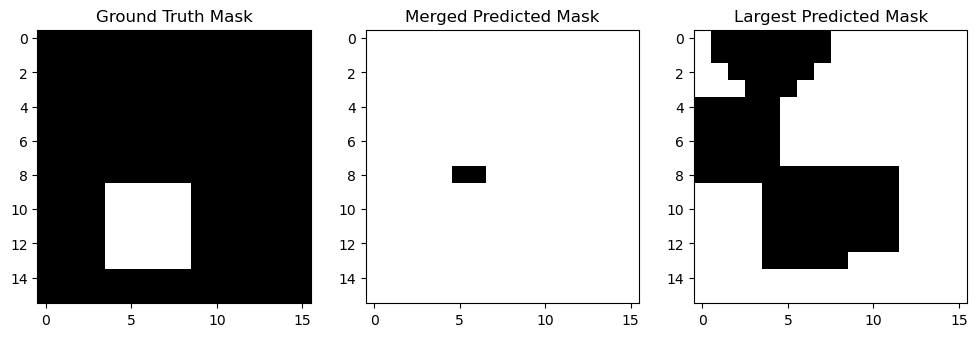


🚀 Epoch 2/5 running...

🖼️ Input Image: shapes_42.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 51
✔ Mask 0 added to merged mask (Size: 89)
✔ Mask 1 added to merged mask (Size: 104)
✔ Mask 2 added to merged mask (Size: 56)
✔ Mask 3 added to merged mask (Size: 1)
✔ Mask 4 added to merged mask (Size: 1)
✔ Mask 5 added to merged mask (Size: 1)
✔ Mask 6 added to merged mask (Size: 1)
✔ Mask 7 added to merged mask (Size: 1)
✔ Mask 8 added to merged mask (Size: 1)
✔ Mask 9 added to merged mask (Size: 1)
✔ Mask 10 added to merged mask (Size: 1)
✔ Mask 11 added to merged mask (Size: 8)
✔ Mask 12 added to merged mask (Size: 3)
✔ Mask 13 added to merged mask (Size: 1)
✔ Mask 14 added to merged mask (Size: 1)
✔ Mask 15 added to merged mask (Size: 3)
✔ Mask 16 added to merged mask (Size: 3)
✔ Mask 17 added to merged mask (Size: 3)
✔ Mask 18 added to merged mask (Size: 3)
✔ Mask 19 added to merged mask (Size: 3)
✔ Mask 20 added to merged mask (Size: 3)
✔ Mask 21 added to merged mask 

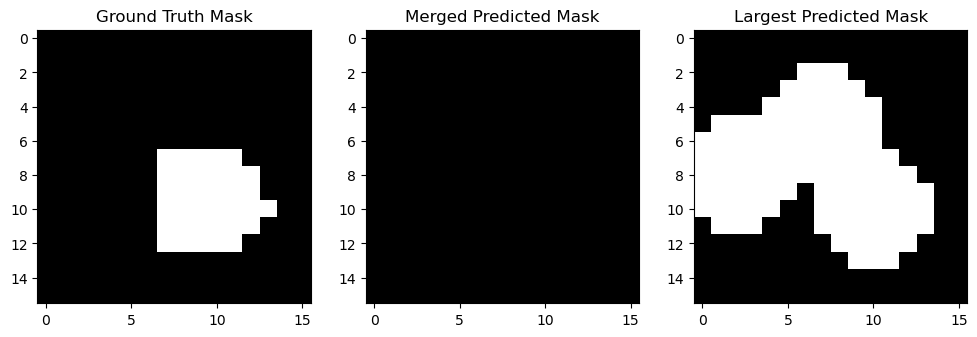


🚀 Epoch 3/5 running...

🖼️ Input Image: shapes_36.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 29
✔ Mask 0 added to merged mask (Size: 186)
✔ Mask 1 added to merged mask (Size: 45)
✔ Mask 2 added to merged mask (Size: 25)
✔ Mask 3 added to merged mask (Size: 3)
✔ Mask 4 added to merged mask (Size: 3)
✔ Mask 5 added to merged mask (Size: 86)
✔ Mask 6 added to merged mask (Size: 70)
✔ Mask 7 added to merged mask (Size: 3)
✔ Mask 8 added to merged mask (Size: 3)
✔ Mask 9 added to merged mask (Size: 3)
✔ Mask 10 added to merged mask (Size: 3)
✔ Mask 11 added to merged mask (Size: 3)
✔ Mask 12 added to merged mask (Size: 5)
✔ Mask 13 added to merged mask (Size: 3)
✔ Mask 14 added to merged mask (Size: 5)
✔ Mask 15 added to merged mask (Size: 5)
✔ Mask 16 added to merged mask (Size: 5)
✔ Mask 17 added to merged mask (Size: 5)
✔ Mask 18 added to merged mask (Size: 5)
✔ Mask 19 added to merged mask (Size: 5)
✔ Mask 20 added to merged mask (Size: 5)
✔ Mask 21 added to merged mas

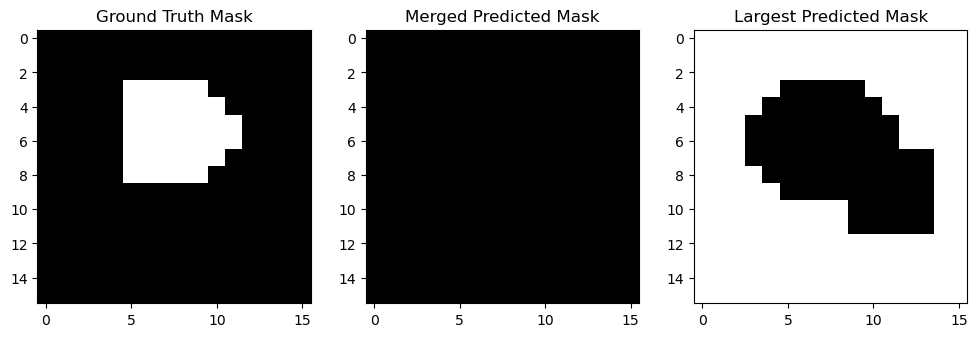


🚀 Epoch 4/5 running...

🖼️ Input Image: shapes_78.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 20
✔ Mask 0 added to merged mask (Size: 169)
✔ Mask 1 added to merged mask (Size: 42)
✔ Mask 2 added to merged mask (Size: 45)
✔ Mask 3 added to merged mask (Size: 25)
✔ Mask 4 added to merged mask (Size: 5)
✔ Mask 5 added to merged mask (Size: 3)
✔ Mask 6 added to merged mask (Size: 3)
✔ Mask 7 added to merged mask (Size: 3)
✔ Mask 8 added to merged mask (Size: 3)
✔ Mask 9 added to merged mask (Size: 3)
✔ Mask 10 added to merged mask (Size: 3)
✔ Mask 11 added to merged mask (Size: 3)
✔ Mask 12 added to merged mask (Size: 3)
✔ Mask 13 added to merged mask (Size: 5)
✔ Mask 14 added to merged mask (Size: 5)
✔ Mask 15 added to merged mask (Size: 3)
✔ Mask 16 added to merged mask (Size: 3)
✔ Mask 17 added to merged mask (Size: 3)
✔ Mask 18 added to merged mask (Size: 5)
✔ Mask 19 added to merged mask (Size: 3)
✅ Merged Predicted Mask Sum: 256.0 (Should be > 0 if detected)
✅ Larges

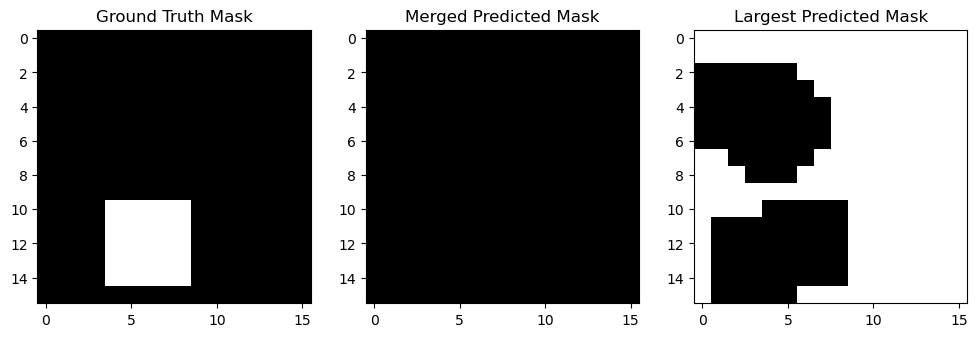


🚀 Epoch 5/5 running...

🖼️ Input Image: shapes_55.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 35
✔ Mask 0 added to merged mask (Size: 188)
✔ Mask 1 added to merged mask (Size: 67)
✔ Mask 2 added to merged mask (Size: 3)
✔ Mask 3 added to merged mask (Size: 3)
✔ Mask 4 added to merged mask (Size: 3)
✔ Mask 5 added to merged mask (Size: 3)
✔ Mask 6 added to merged mask (Size: 3)
✔ Mask 7 added to merged mask (Size: 3)
✔ Mask 8 added to merged mask (Size: 3)
✔ Mask 9 added to merged mask (Size: 3)
✔ Mask 10 added to merged mask (Size: 3)
✔ Mask 11 added to merged mask (Size: 3)
✔ Mask 12 added to merged mask (Size: 3)
✔ Mask 13 added to merged mask (Size: 3)
✔ Mask 14 added to merged mask (Size: 3)
✔ Mask 15 added to merged mask (Size: 3)
✔ Mask 16 added to merged mask (Size: 3)
✔ Mask 17 added to merged mask (Size: 4)
✔ Mask 18 added to merged mask (Size: 3)
✔ Mask 19 added to merged mask (Size: 3)
✔ Mask 20 added to merged mask (Size: 3)
✔ Mask 21 added to merged mask (

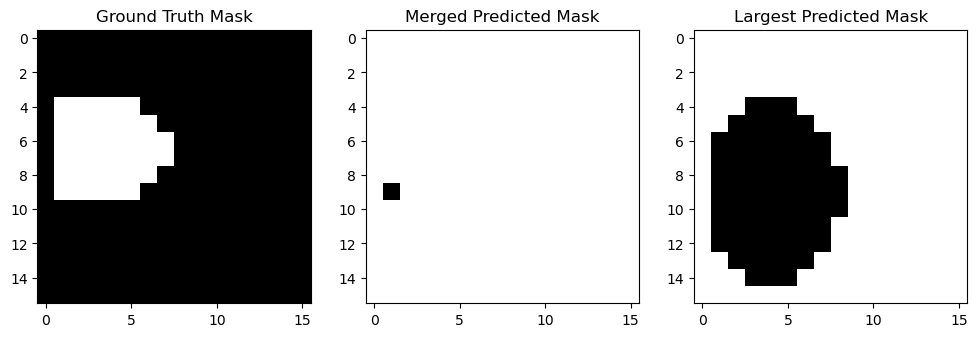


📊 **Epoch Results Summary**
Epoch 1: shapes_0.png -> IoU (Merged): 1.0000, Dice (Merged): 1.0000 | IoU (Largest): 1.0000, Dice (Largest): 1.0000
Epoch 2: shapes_42.png -> IoU (Merged): 0.0000, Dice (Merged): 0.0000 | IoU (Largest): 1.0000, Dice (Largest): 1.0000
Epoch 3: shapes_36.png -> IoU (Merged): 0.0000, Dice (Merged): 0.0000 | IoU (Largest): 1.0000, Dice (Largest): 1.0000
Epoch 4: shapes_78.png -> IoU (Merged): 0.0000, Dice (Merged): 0.0000 | IoU (Largest): 1.0000, Dice (Largest): 1.0000
Epoch 5: shapes_55.png -> IoU (Merged): 1.0000, Dice (Merged): 1.0000 | IoU (Largest): 1.0000, Dice (Largest): 1.0000


In [215]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# Function to compute IoU and Dice
def compute_iou(pred_mask, gt_mask):
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    union = torch.logical_or(pred_mask, gt_mask).sum().item()
    
    return intersection / union if union > 0 else 0.0

def compute_dice(pred_mask, gt_mask):
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    total = pred_mask.sum().item() + gt_mask.sum().item()
    
    return (2 * intersection) / total if total > 0 else 0.0


# 🚀 Number of epochs
NUM_EPOCHS = 5  

# Store results
epoch_results = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...\n")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = f"./shapes_dataset_16x16/dataset/images/{image_filename}"

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"🖼️ Input Image: {image_filename} | Shape Before SAM: {image.shape}")

    # Get GT annotations
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM
    sam_result = mask_generator.generate(image)
    print(f"✅ Total detected masks: {len(sam_result)}")

    # 🏆 Compare different strategies for predicted masks
    merged_predicted_mask = np.zeros((16, 16), dtype=np.uint8)  
    largest_mask = None
    max_mask_size = 0

    # Process SAM predicted masks
    for idx, mask in enumerate(sam_result):
        sam_mask = mask['segmentation']
        
        # Ensure correct shape
        if sam_mask.shape != (16, 16):
            sam_mask = cv2.resize(sam_mask.astype(np.uint8), (16, 16), interpolation=cv2.INTER_NEAREST)

        # Merge all masks
        merged_predicted_mask = np.logical_or(merged_predicted_mask, sam_mask)

        # Find the largest mask
        mask_size = sam_mask.sum()
        if mask_size > max_mask_size:
            max_mask_size = mask_size
            largest_mask = sam_mask

        print(f"✔ Mask {idx} added to merged mask (Size: {mask_size})")

    # Convert to PyTorch tensor
    merged_predicted_mask = torch.tensor(merged_predicted_mask).float()
    if largest_mask is not None:
        largest_predicted_mask = torch.tensor(largest_mask).float()
    else:
        largest_predicted_mask = merged_predicted_mask  # Fallback

    print(f"✅ Merged Predicted Mask Sum: {merged_predicted_mask.sum().item()} (Should be > 0 if detected)")
    print(f"✅ Largest Predicted Mask Sum: {largest_predicted_mask.sum().item()} (Should be > 0 if detected)")

    # 🚀 Load Ground Truth Mask
    gt_mask = np.zeros((16, 16), dtype=np.uint8)
    
    for ann in image_annotations:
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)

        # Print GT segmentation before rescaling
        print(f"🔍 GT Segmentation Before Scaling: {segmentation}")

        # Scale GT coordinates if needed
        if np.max(segmentation) <= 1.0:
            segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale to pixel coordinates
        
        segmentation = segmentation.astype(np.int32)

        # Create the GT mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        break  

    # Convert to PyTorch tensor
    gt_mask = torch.tensor(gt_mask).float()
    print(f"✅ GT Mask Shape: {gt_mask.shape}")

    # ⚠ Apply Z-Normalization on masks
    def z_normalize(mask):
        return (mask - mask.mean()) / (mask.std() + 1e-8)

    merged_predicted_mask = z_normalize(merged_predicted_mask)
    largest_predicted_mask = z_normalize(largest_predicted_mask)
    gt_mask = z_normalize(gt_mask)

    # Compute IoU & Dice Scores
    iou_merged = compute_iou(merged_predicted_mask, gt_mask)
    dice_merged = compute_dice(merged_predicted_mask, gt_mask)

    iou_largest = compute_iou(largest_predicted_mask, gt_mask)
    dice_largest = compute_dice(largest_predicted_mask, gt_mask)

    print(f"🔍 IoU Calculation - Pred Mask Shape: {merged_predicted_mask.shape}, GT Mask Shape: {gt_mask.shape}")
    print(f"🔍 Overlapping Pixels: {torch.logical_and(merged_predicted_mask, gt_mask).sum().item()}, Union Pixels: {torch.logical_or(merged_predicted_mask, gt_mask).sum().item()}")
    
    print(f"🔍 Dice Calculation - Intersection: {torch.logical_and(merged_predicted_mask, gt_mask).sum().item()}, Total Pixels in Both Masks: {merged_predicted_mask.sum().item() + gt_mask.sum().item()}")

    # Store results
    epoch_results.append({
        "epoch": epoch,
        "image": image_filename,
        "iou_merged": iou_merged,
        "dice_merged": dice_merged,
        "iou_largest": iou_largest,
        "dice_largest": dice_largest
    })

    # 📊 Comparison Output
    print("\n📊 **Comparison of Merging All Masks vs Using Largest Mask**")
    print(f"🔹 Merged Masks -> IoU: {iou_merged:.4f}, Dice Score: {dice_merged:.4f}")
    print(f"🔹 Largest Mask -> IoU: {iou_largest:.4f}, Dice Score: {dice_largest:.4f}")
    print("✅ Using merged masks for final evaluation.")

    # 📈 Visualization
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
    plt.title("Ground Truth Mask")

    plt.subplot(1, 3, 2)
    plt.imshow(merged_predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Merged Predicted Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(largest_predicted_mask.cpu().numpy(), cmap="gray")
    plt.title("Largest Predicted Mask")

    plt.show()

# 📊 Final Summary
print("\n📊 **Epoch Results Summary**")
for result in epoch_results:
    print(f"Epoch {result['epoch']}: {result['image']} -> IoU (Merged): {result['iou_merged']:.4f}, Dice (Merged): {result['dice_merged']:.4f} | IoU (Largest): {result['iou_largest']:.4f}, Dice (Largest): {result['dice_largest']:.4f}")